In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder

In [2]:
df=pd.read_csv('adult.csv')

In [3]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
for col in df.columns:
    print(col)
    print(df[col].unique())

age
[90 82 66 54 41 34 38 74 68 45 52 32 51 46 57 22 37 29 61 21 33 49 23 59
 60 63 53 44 43 71 48 73 67 40 50 42 39 55 47 31 58 62 36 72 78 83 26 70
 27 35 81 65 25 28 56 69 20 30 24 64 75 19 77 80 18 17 76 79 88 84 85 86
 87]
workclass
['?' 'Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc' 'Self-emp-inc'
 'Local-gov' 'Without-pay' 'Never-worked']
fnlwgt
[ 77053 132870 186061 ...  34066  84661 257302]
education
['HS-grad' 'Some-college' '7th-8th' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters' '11th' 'Assoc-acdm' 'Assoc-voc' '1st-4th' '5th-6th'
 '12th' '9th' 'Preschool']
education.num
[ 9 10  4  6 16 15 13 14  7 12 11  2  3  8  5  1]
marital.status
['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']
occupation
['?' 'Exec-managerial' 'Machine-op-inspct' 'Prof-specialty'
 'Other-service' 'Adm-clerical' 'Craft-repair' 'Transport-moving'
 'Handlers-cleaners' 'Sales' 'Farming-fishing' 'Tech-support'
 'Protective-

#### 1.Handle missing values as per the best practices (imputation, removal, etc.).


In [6]:
### checking duplicates
df.duplicated().sum()

np.int64(24)

In [7]:
df[df.duplicated()]

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
8453,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
8645,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
12202,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
14346,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
15603,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
17344,21,Private,243368,Preschool,1,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,50,Mexico,<=50K
19067,46,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
20388,30,Private,144593,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,?,<=50K
20507,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
22783,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [8]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [9]:
## Missing values
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [10]:
df['native.country'].replace('?',np.nan,inplace=True)
df['occupation'].replace('?',np.nan,inplace=True)
df['workclass'].replace('?',np.nan,inplace=True)

In [11]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     582
income               0
dtype: int64

In [12]:
df.fillna({'workclass':df.workclass.mode()[0],
          'occupation':df.occupation.mode()[0],
          'native.country':df['native.country'].mode()[0]},inplace=True)

In [13]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

#### 2.Encoding Techniques:

In [14]:
df.income= np.where(df.income=='<=50K',0,1)
target= df[['income']]
features= df.drop(columns=['income'])
target.income.unique()

array([0, 1])

<Axes: >

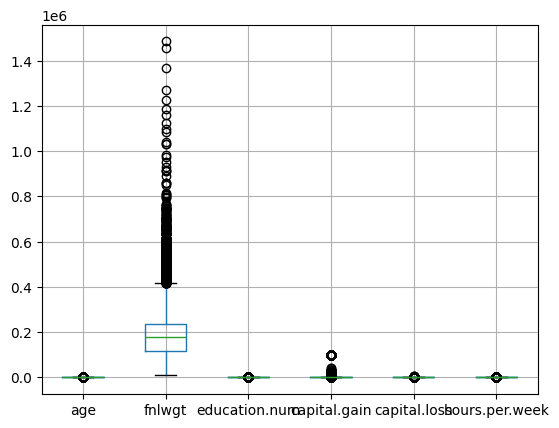

In [15]:
features.boxplot()

In [16]:
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3= df[columns].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[columns]= df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in features.select_dtypes(include=['int','float']).columns:
    outlier_capping(features,col)

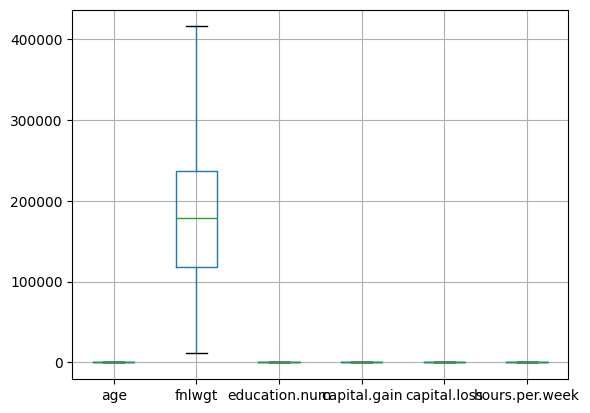

In [17]:
features.boxplot()
plt.show()

In [18]:
cat_col=features.select_dtypes(include=['object']).columns
print(cat_col)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')


In [19]:
features.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,78.0,Private,77053.0,HS-grad,9.0,Widowed,Prof-specialty,Not-in-family,White,Female,0.0,0.0,40.0,United-States
1,78.0,Private,132870.0,HS-grad,9.0,Widowed,Exec-managerial,Not-in-family,White,Female,0.0,0.0,32.5,United-States
2,66.0,Private,186061.0,Some-college,10.0,Widowed,Prof-specialty,Unmarried,Black,Female,0.0,0.0,40.0,United-States
3,54.0,Private,140359.0,7th-8th,4.5,Divorced,Machine-op-inspct,Unmarried,White,Female,0.0,0.0,40.0,United-States
4,41.0,Private,264663.0,Some-college,10.0,Separated,Prof-specialty,Own-child,White,Female,0.0,0.0,40.0,United-States


In [20]:
features.shape

(32537, 14)

In [21]:
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=100,stratify=target.income)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(26029, 14)
(6508, 14)
(26029, 1)
(6508, 1)


In [22]:
x_train.reset_index(drop=True,inplace=True)
x_test.reset_index(drop=True,inplace=True)
x_train.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,19.0,Without-pay,43887.0,HS-grad,9.0,Never-married,Farming-fishing,Own-child,White,Male,0.0,0.0,32.5,United-States
1,58.0,Private,216851.0,9th,5.0,Never-married,Handlers-cleaners,Own-child,White,Male,0.0,0.0,40.0,El-Salvador
2,42.0,State-gov,155657.0,HS-grad,9.0,Divorced,Adm-clerical,Not-in-family,Black,Female,0.0,0.0,32.5,United-States
3,43.0,Private,211860.0,HS-grad,9.0,Never-married,Other-service,Unmarried,Black,Female,0.0,0.0,32.5,United-States
4,31.0,Private,145377.0,Bachelors,13.0,Married-civ-spouse,Sales,Husband,White,Male,0.0,0.0,52.5,United-States


In [23]:
## ordinal 
ord_enc=OrdinalEncoder()

In [24]:
x_train['education']= ord_enc.fit_transform(x_train[['education']])
x_test['education']= ord_enc.transform(x_test[['education']])

In [25]:
pd.get_dummies(x_train).shape

(26029, 90)

In [26]:
pd.get_dummies(x_test).shape

(6508, 89)

In [27]:
cat_col=features.select_dtypes(include=['object']).columns
print(cat_col)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')


In [28]:
### one hot method
one_hot= OneHotEncoder(sparse_output=False, handle_unknown='ignore')
x_train_enc=pd.DataFrame(data=one_hot.fit_transform(x_train[cat_col]),columns=one_hot.get_feature_names_out())
x_test_enc= pd.DataFrame(data=one_hot.transform(x_test[cat_col]),columns=one_hot.get_feature_names_out()) 
x_train_enc.shape, x_test_enc.shape

((26029, 99), (6508, 99))

In [29]:
x_train_enc.head()

,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_0.0,education_1.0,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [30]:
x_train.drop(columns=cat_col,inplace=True)
x_test.drop(columns=cat_col, inplace=True)

In [31]:
x_train.shape, x_test.shape

((26029, 6), (6508, 6))

In [32]:
x_train_final= pd.concat([x_train,x_train_enc],axis=1)
x_train_final.shape

(26029, 105)

In [33]:
x_test_final= pd.concat([x_test,x_test_enc],axis=1)
x_test_final.shape

(6508, 105)

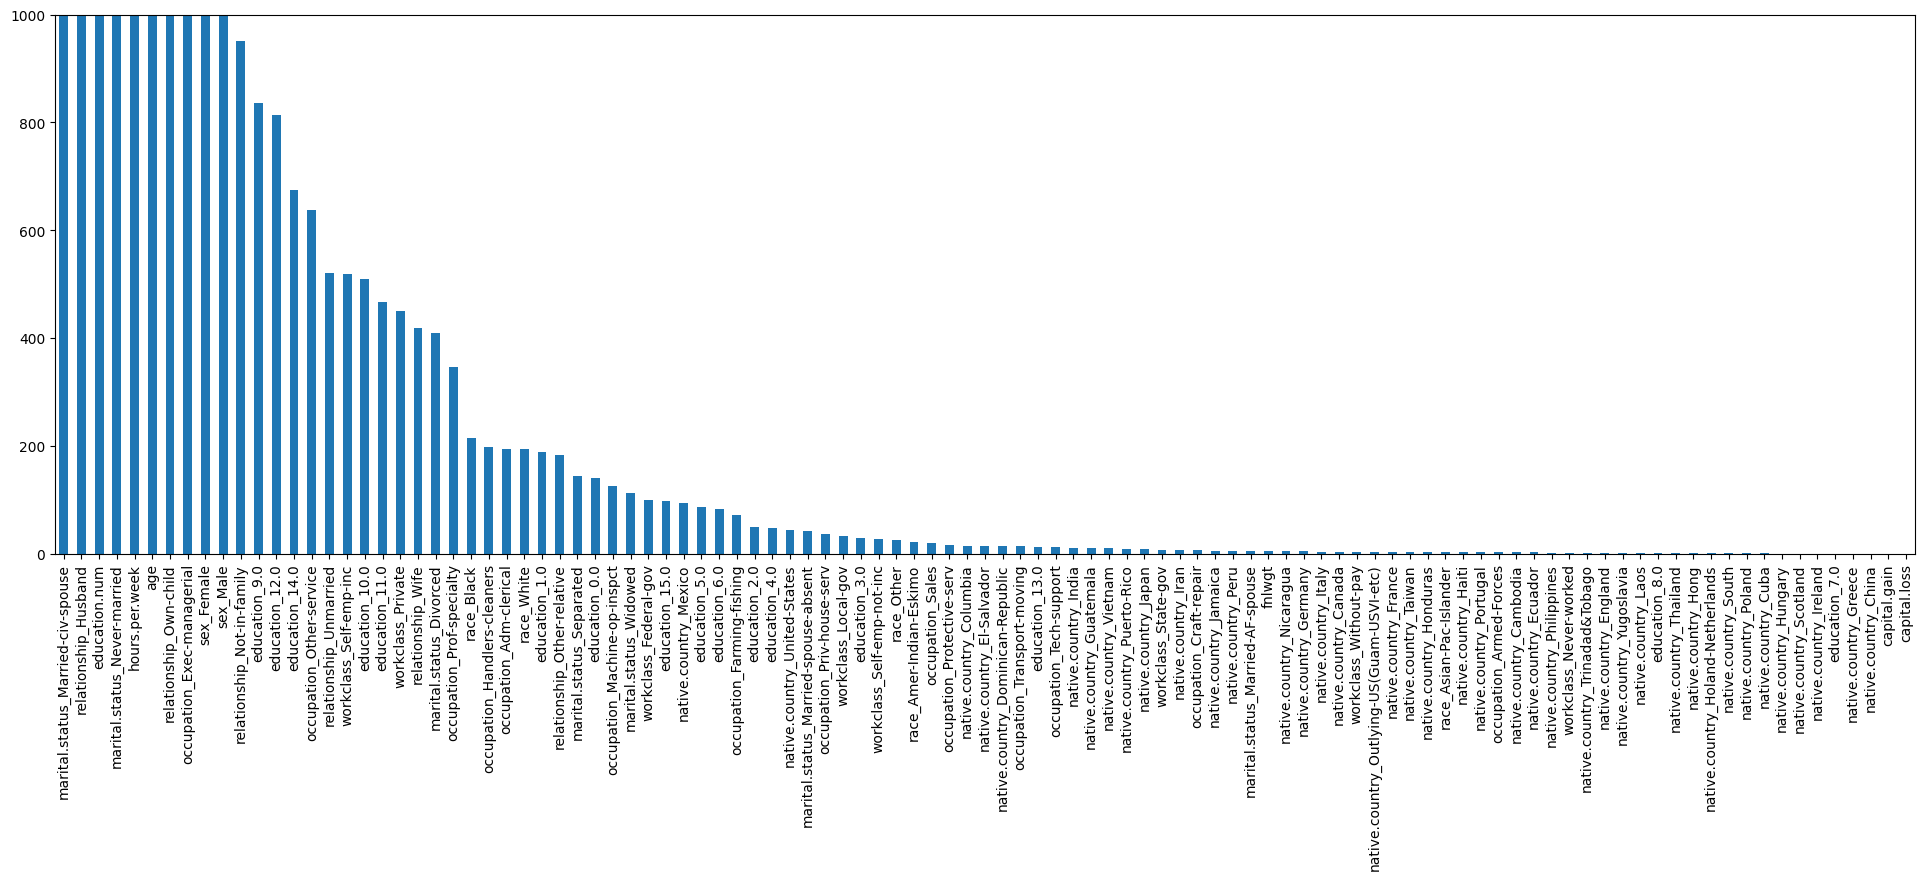

In [34]:
plt.figure(figsize=(24,7))
f_clas= f_classif(x_train_final,y_train)
pd.Series(f_clas[0],index=x_train_final.columns).sort_values(ascending=False).plot(kind='bar')
plt.ylim(0,1000)
plt.show()

In [35]:
### Scaling
std_sca=StandardScaler()
x_train_final[['age','fnlwgt','hours.per.week']]= std_sca.fit_transform(x_train_final[['age','fnlwgt','hours.per.week']])
x_test_final[['age','fnlwgt','hours.per.week']]= std_sca.transform(x_test_final[['age','fnlwgt','hours.per.week']])

In [36]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
ada_boost= AdaBoostClassifier(estimator=LogisticRegression(), n_estimators=100,random_state=50)
ada_boost.fit(x_train_final,y_train)
y_pred= ada_boost.predict(x_test_final)
accuracy_score(y_test,y_pred)

0.8206822372464659

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32537 non-null  int64 
 1   workclass       32537 non-null  object
 2   fnlwgt          32537 non-null  int64 
 3   education       32537 non-null  object
 4   education.num   32537 non-null  int64 
 5   marital.status  32537 non-null  object
 6   occupation      32537 non-null  object
 7   relationship    32537 non-null  object
 8   race            32537 non-null  object
 9   sex             32537 non-null  object
 10  capital.gain    32537 non-null  int64 
 11  capital.loss    32537 non-null  int64 
 12  hours.per.week  32537 non-null  int64 
 13  native.country  32537 non-null  object
 14  income          32537 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 3.7+ MB


In [37]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329,0.240926
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889,0.427652
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


####  3. Feature Engineering:

In [42]:
df['age_group'] = pd.cut(df['age'], bins=[0,25,50,100], labels=['Young','Adult','Senior'])

In [43]:
df['work_hours'] = pd.cut(df['hours.per.week'], bins=[0,25,40,100], labels=['Part-time','Full-time','Overtime'])

In [44]:
df['capital.gain'] = np.log1p(df['capital.gain'])

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             32537 non-null  int64   
 1   workclass       32537 non-null  object  
 2   fnlwgt          32537 non-null  int64   
 3   education       32537 non-null  object  
 4   education.num   32537 non-null  int64   
 5   marital.status  32537 non-null  object  
 6   occupation      32537 non-null  object  
 7   relationship    32537 non-null  object  
 8   race            32537 non-null  object  
 9   sex             32537 non-null  object  
 10  capital.gain    32537 non-null  float64 
 11  capital.loss    32537 non-null  int64   
 12  hours.per.week  32537 non-null  int64   
 13  native.country  32537 non-null  object  
 14  income          32537 non-null  int64   
 15  age_group       32537 non-null  category
 16  work_hours      32537 non-null  category
dtypes: category(